### Data Preprocessing, add tatical features.

In [8]:
import pandas as pd
import os
from IPython.display import display 
from src.data_pipeline.feature_engineering import main_data_pipeline
from src.data_pipeline.clean import main_clean_pipeline

BASE_DIR = "./data"

# ------------------------------------------
# Paths
# ------------------------------------------
tournament_csv_path = os.path.join(BASE_DIR, "tournament.csv")
match_csv_path = os.path.join(BASE_DIR, "match.csv")
set_csv_path = os.path.join(BASE_DIR, "set.csv")
rally_csv_path = os.path.join(BASE_DIR, "rally.csv")
shot_csv_path = os.path.join(BASE_DIR, "shot.csv")

# ------------------------------------------
# Columns Config
# ------------------------------------------
tournament_cols_to_keep = ['tournament_id', 'level']
match_cols_to_keep = ['match_id', 'event', 'tournament_id', 'duration', 'set_count']

shot_cols_to_remove = ['time', 'start_frame_num', 'end_frame_num', 'set_num', 
                       'current_win_score', 'current_lose_score', 'lose_reason', 'score_team']
rally_cols_to_remove = ['start_frame', 'end_frame', 'comment', 'rally_video_check', 
                        'score_reason', 'shot_count']

# ------------------------------------------
# Data Loading & Preprocessing
# ------------------------------------------
# Tournament
tournament_data = pd.read_csv(tournament_csv_path, usecols=tournament_cols_to_keep)
tournament_data['level'] = tournament_data['level'].astype(str).str.replace('Super ', '', case=False).str.strip()

# Match
match_data = pd.read_csv(match_csv_path, usecols=match_cols_to_keep)
match_data['match_id'] = pd.to_numeric(match_data['match_id'], errors='coerce').astype('Int64')
match_data['event'] = pd.to_numeric(match_data['event'], errors='coerce').astype('Int64')

# Set
set_data = pd.read_csv(set_csv_path)
set_data['match_id'] = pd.to_numeric(set_data['match_id'], errors='coerce').astype('Int64')

# Rally
rally_data = pd.read_csv(rally_csv_path, usecols=lambda c: c not in rally_cols_to_remove)

# Shot
shot_data = pd.read_csv(shot_csv_path, usecols=lambda c: c not in shot_cols_to_remove)
shot_data = main_clean_pipeline(shot_data)

print(f"tournament_data.head():\n{tournament_data.head()}\n")
print(f"match_data.head():\n{match_data.head()}\n")
print(f"set_data.head():\n{set_data.head()}\n")
print(f"rally_data.head():\n{rally_data.head()}\n")
print(f"shot_data.head():\n{shot_data.head()}\n")

# ------------------------------------------
# Merging Pipeline
# ------------------------------------------
df_match_rally_shot = (
    shot_data
    .merge(rally_data, on='rally_id', how='left')
    .merge(set_data, on='set_id', how='left')
    .merge(match_data, on='match_id', how='left')
    .merge(tournament_data, on='tournament_id', how='left')
)

full_df = main_data_pipeline(df_match_rally_shot, CCE_Radius=9)

print(f"(rows, columns): {full_df.shape}")
print("Effective features:\n", full_df.columns.tolist())
print(full_df.head(10)) 

OUTPUT_FILE = os.path.join(BASE_DIR, "merge_data.csv")
full_df.to_csv(OUTPUT_FILE, index=False)


[Start Data Clean]...

--- Data Clean Result ---
Origin 58359 rows
Remove 519 rows (coordinate outlier/unclassified/hit_height=0/Error Case)
Final 57840 rows
--- remove result ---
Origin 57840 rows。
363 rally of Exception
Remove 3699 rows。
Final 54141 rows。

[Data Clean Finished]
tournament_data.head():
   tournament_id              level
0              1  World Tour Finals
1              2                300
2              3                500
3              4               1000
4              5               1000

match_data.head():
   match_id  event  tournament_id  set_count  duration
0         2      1              2          2        37
1         4      2              2          2        54
2         5      1              3          2        36
3         6      1              3          2        33
4         7      3              3          2        38

set_data.head():
   set_id  match_id  set_num  win_score  lose_score  set_win
0       1         2        1         21          

In [1]:
import pandas as pd
import os
BASE_DIR = "./data"

full_df_path = os.path.join(BASE_DIR, "merge_data.csv")
full_df = pd.read_csv(full_df_path)

/tmp/ipykernel_1851635/1187254837.py:6: DtypeWarning: Columns (0: level, 1: next_winner_mid_cover, 2: next_loser_mid_cover) have mixed types. Specify dtype option on import or set low_memory=False.
  full_df = pd.read_csv(full_df_path)


findfont: Font family ['Microsoft JhengHei'] not found. Falling back to DejaVu Sans.
/home/chien/Desktop/DShuttleNet/src/analysis/general_analyze.py:132: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


Successfully loaded data, initial number of events: 54141
Filtered out Angle=-404.0 and invalid rows, final number of valid shots: 49579

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Defensive Shot    0.66
Offensive Shot    0.34
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Zone
Backcourt    0.27
Forecourt    0.10
Midcourt     0.62
Name: Count, dtype: float64
--------------------



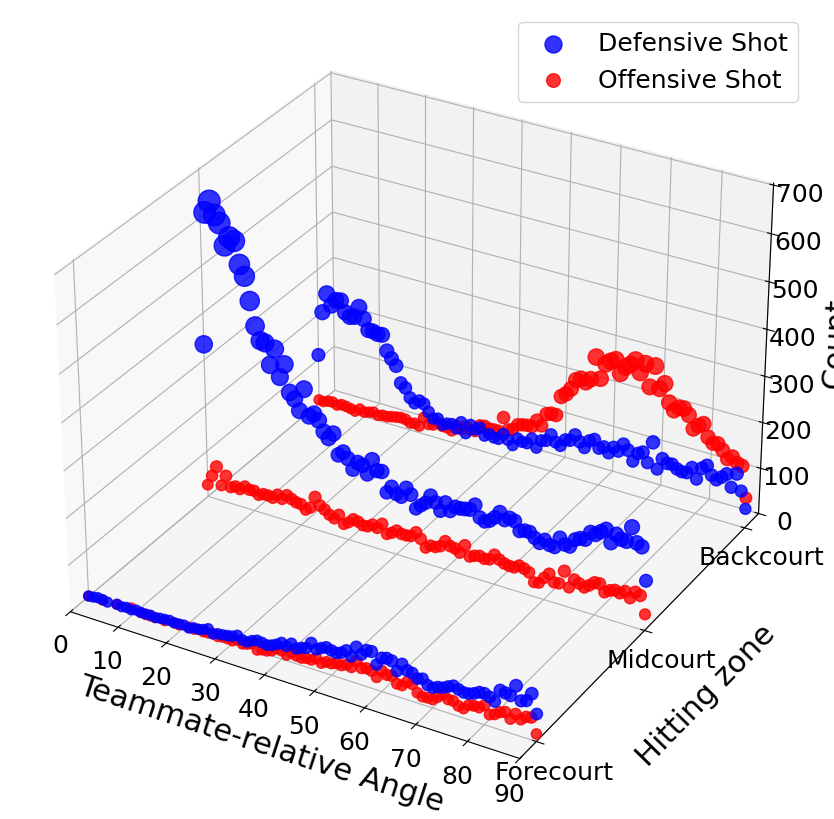

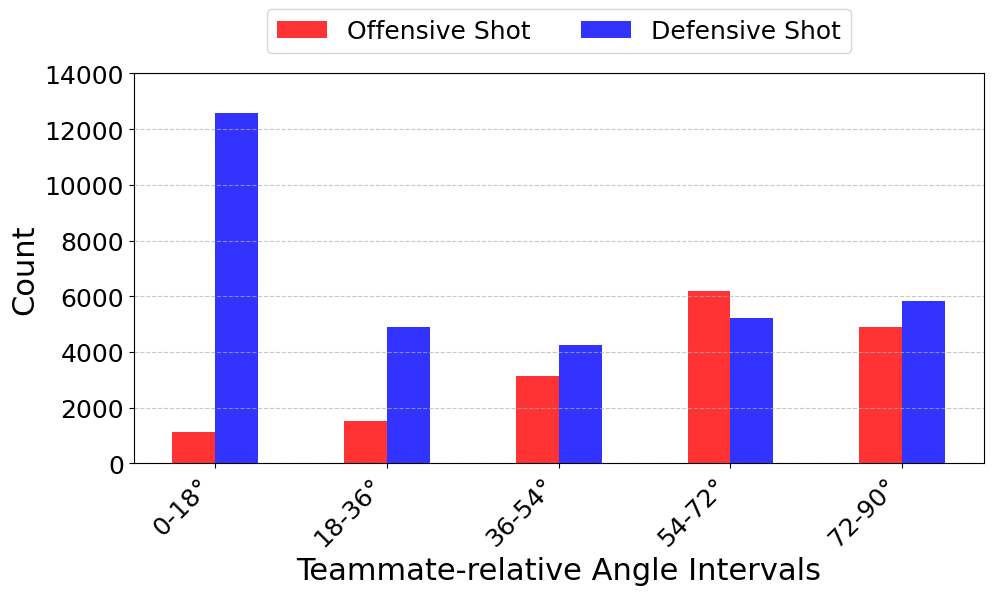

Successfully loaded data, original event count: 54141
Filtered Angle=-404.0 and invalid rows, final valid shot events: 49579
Filtered BallType: ['long serve', 'short serve', 'uncategorized']

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Downward Shot    0.38
Flat Shot        0.28
Upward Shot      0.35
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Series([], Name: Count, dtype: float64)
--------------------



/home/chien/Desktop/DShuttleNet/src/analysis/general_analyze.py:311: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


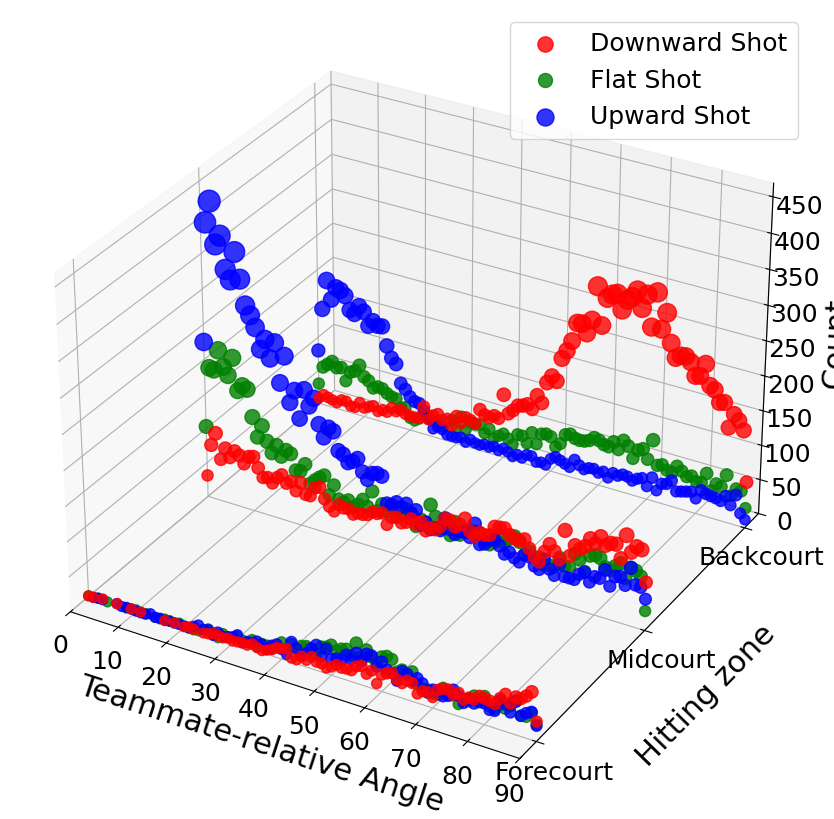

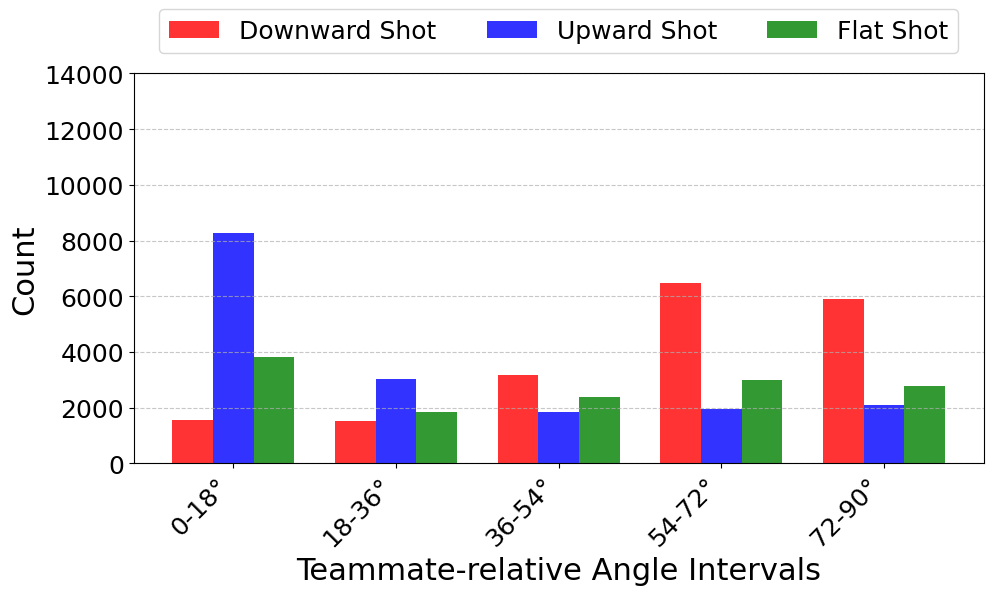

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
from src.analysis.general_analyze import plot_badminton_shot_analysis, plot_badminton_VSA_analysis, analyze_badminton_rally_stats,  analyze_badminton_shot_distribution


plot_badminton_shot_analysis(full_df)
plot_badminton_VSA_analysis(full_df)

In [3]:
analyze_badminton_rally_stats(full_df)
analyze_badminton_shot_distribution(full_df)

=== Badminton Rally/Shot Statistics ===
event_name  total_rallies  total_shots  average_shots_per_rally  max_shots  min_shots
        MD           1841        15344                     8.33         60          1
        WD           1843        31737                    17.22        186          1
        XD            799         7060                     8.84         60          1
----------------------------------------
Total Rallies: 4483
Total Shots: 54141
Average Shots per Rally: 12.08

--- Final Analysis Report [Count (Percentage)] ---
                        MD             WD             XD           Total
Drop           534 (3.48%)   2632 (8.29%)    232 (3.29%)    3398 (6.28%)
Long Serve     237 (1.54%)    222 (0.70%)    136 (1.93%)     595 (1.10%)
Short Serve  1601 (10.43%)   1620 (5.10%)    662 (9.38%)    3883 (7.17%)
Drive        2950 (19.23%)  3803 (11.98%)  1141 (16.16%)   7894 (14.58%)
Lift         2171 (14.15%)  7984 (25.16%)   919 (13.02%)  11074 (20.45%)
Push/Rush    15

,MD,WD,XD,Total
Drop,534 (3.48%),2632 (8.29%),232 (3.29%),3398 (6.28%)
Long Serve,237 (1.54%),222 (0.70%),136 (1.93%),595 (1.10%)
Short Serve,1601 (10.43%),1620 (5.10%),662 (9.38%),3883 (7.17%)
Drive,2950 (19.23%),3803 (11.98%),1141 (16.16%),7894 (14.58%)
Lift,2171 (14.15%),7984 (25.16%),919 (13.02%),11074 (20.45%)
Push/Rush,1550 (10.10%),1929 (6.08%),626 (8.87%),4105 (7.58%)
Smash,2297 (14.97%),6165 (19.43%),901 (12.76%),9363 (17.29%)
Net Shot,3836 (25.00%),5111 (16.10%),2319 (32.85%),11266 (20.81%)
Clear,163 (1.06%),2257 (7.11%),122 (1.73%),2542 (4.70%)
Total,15344,31737,7060,54141


Analyzing: A total of 26351 hits under the 'Attack' formation.
Original attack samples: 24105 | After excluding opponent errors, actual tested samples: 22579

[Tested State Transition Frequency Table (Counts)]
next_state_strict  Keep Attack  To Defense  Point Lost
is_reaction_cover                                     
False                     5087        4017         341
True                      8780        4013         341

[Strict Formation Transition Probability Analysis (%)]
next_state_strict          Keep Attack  To Defense  Point Lost
No Coverage (CCEI=False)         53.86       42.53        3.61
With Coverage (CCEI=True)        66.85       30.55        2.60


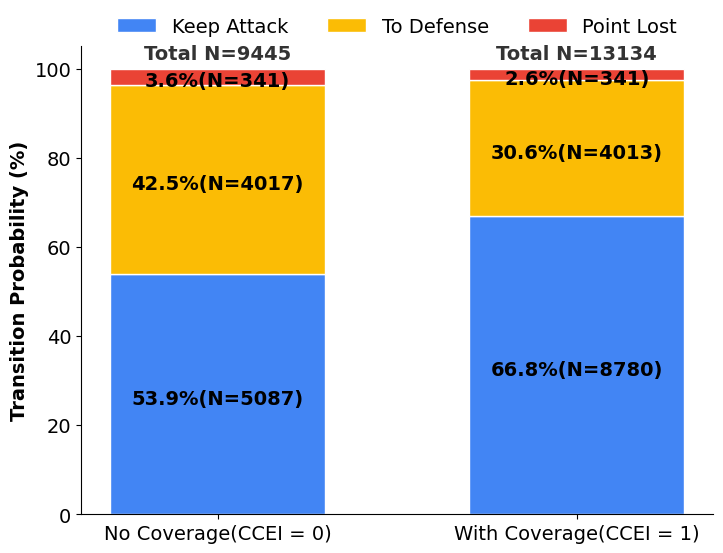

next_state_strict,Keep Attack,To Defense,Point Lost
No Coverage (CCEI=False),53.859185,42.530439,3.610376
With Coverage (CCEI=True),66.849399,30.554287,2.596315


In [4]:
from src.analysis.ccei_analysis import formation_change_ccei_analysis
formation_change_ccei_analysis(full_df)

 There are 10796 valid records for defense analysis.

[Logistic Regression Analysis for Nonlinear TLAI Effect]
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.9891      0.060    -33.080      0.000      -2.107      -1.871
TLAI_scaled_10x    -0.0229      0.058     -0.394      0.694      -0.137       0.091
TLAI_squared        0.0373      0.011      3.436      0.001       0.016       0.059

>> Coefficient for quadratic term (TLAI_squared) : 0.0373
>> P-value: 0.00059

[TLAI threshold analysis (only showing intervals with sample size >= 100)]
  TLAI_bin  Failure_Rate  Sample_Count
0     0.00     12.881639          2391
1     0.05     11.840968          2314
2     0.10     10.493506          1925
3     0.15     12.844612          1596
4     0.20     15.279138          1021
5     0.25     15.728477           604
6     0.30     15.068493           365
7 

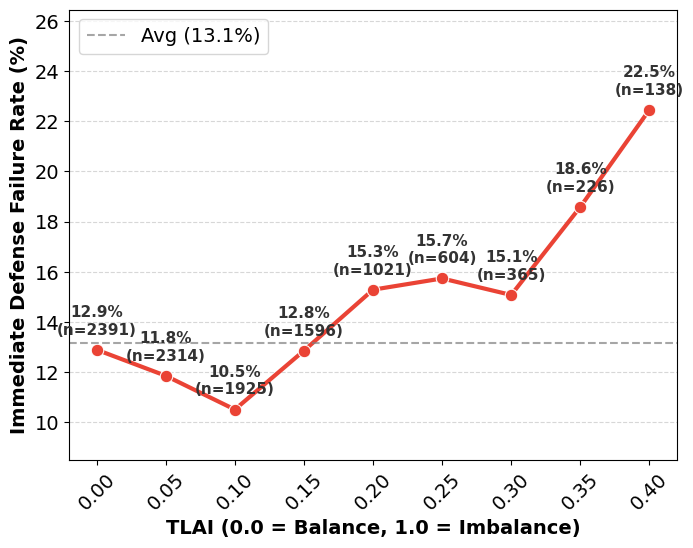

,TLAI_bin,Failure_Rate,Sample_Count
0,0.00,12.881639,2391
1,0.05,11.840968,2314
2,0.10,10.493506,1925
3,0.15,12.844612,1596
4,0.20,15.279138,1021
5,0.25,15.728477,604
6,0.30,15.068493,365
7,0.35,18.584071,226
8,0.40,22.463768,138
9,0.45,16.304348,92


In [6]:
from src.analysis.tlai_analysis import analyze_tlai
analyze_tlai(full_df, threat_shot_types = ['Smash', 'Drop'])

Successfully saved plot to: ./img/matches/intensity_analysis.png


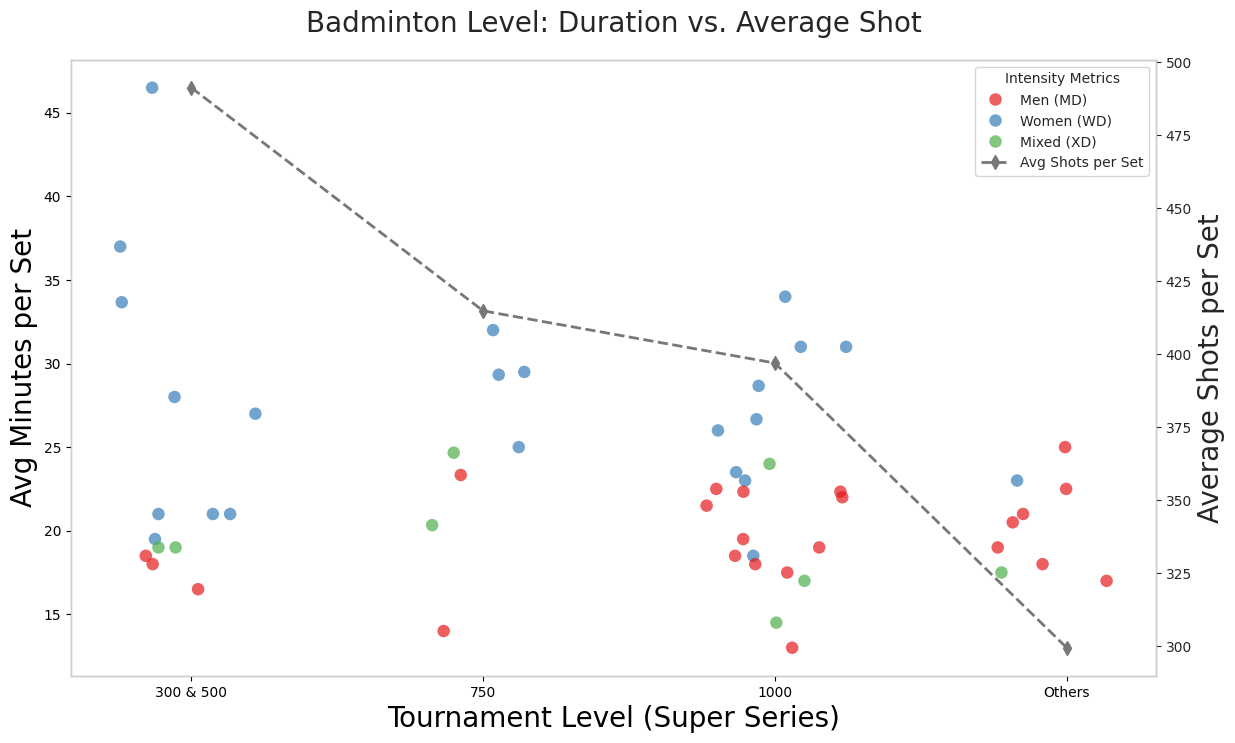

In [9]:
from src.analysis.matches_analyze import plot_badminton_intensity

match_tour_data = pd.merge(
        left=match_data,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )
plot_badminton_intensity(match_tour_data,df_match_rally_shot)

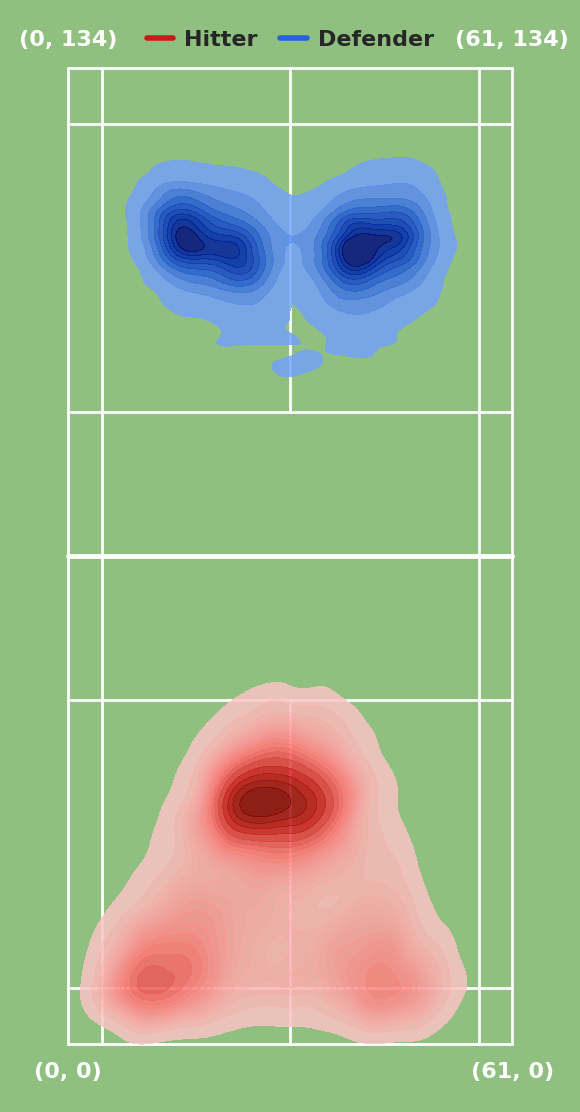

img/shottype_pos/smash.png (400 DPI) successfully saved!


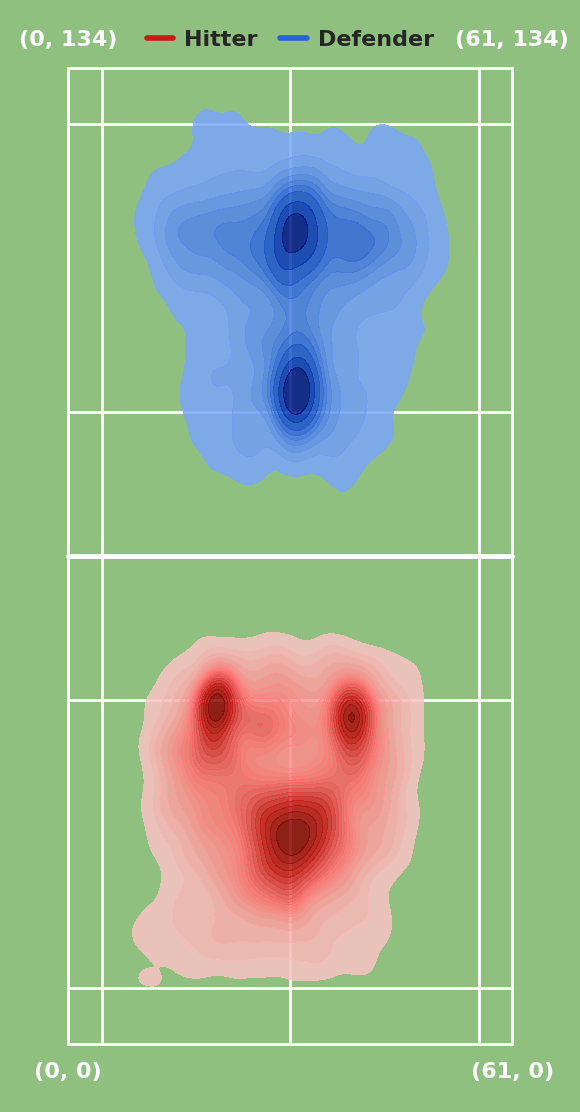

img/shottype_pos/push.png (400 DPI) successfully saved!


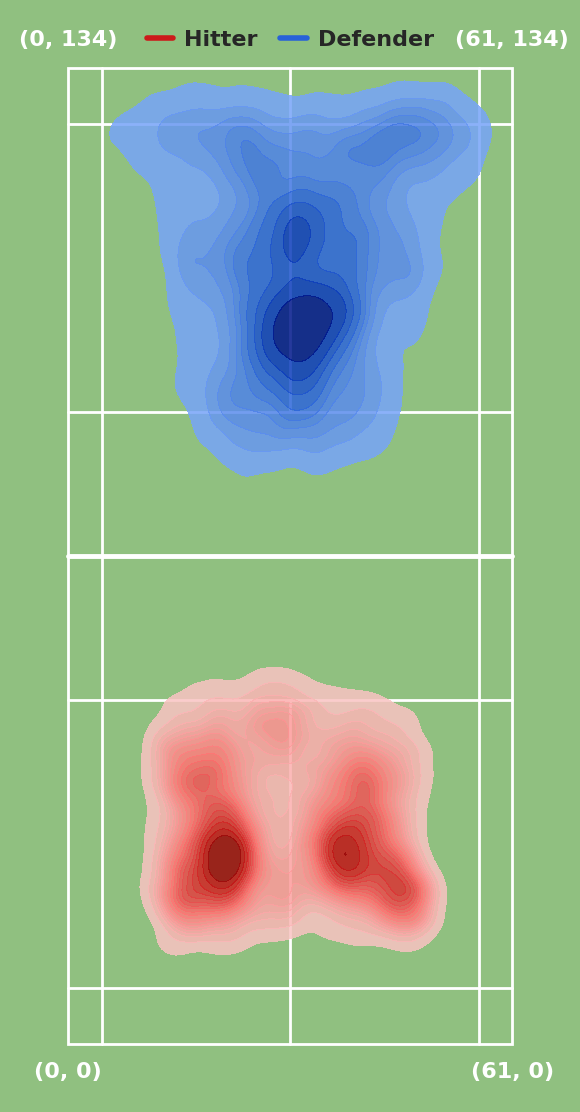

img/shottype_pos/lift.png (400 DPI) successfully saved!


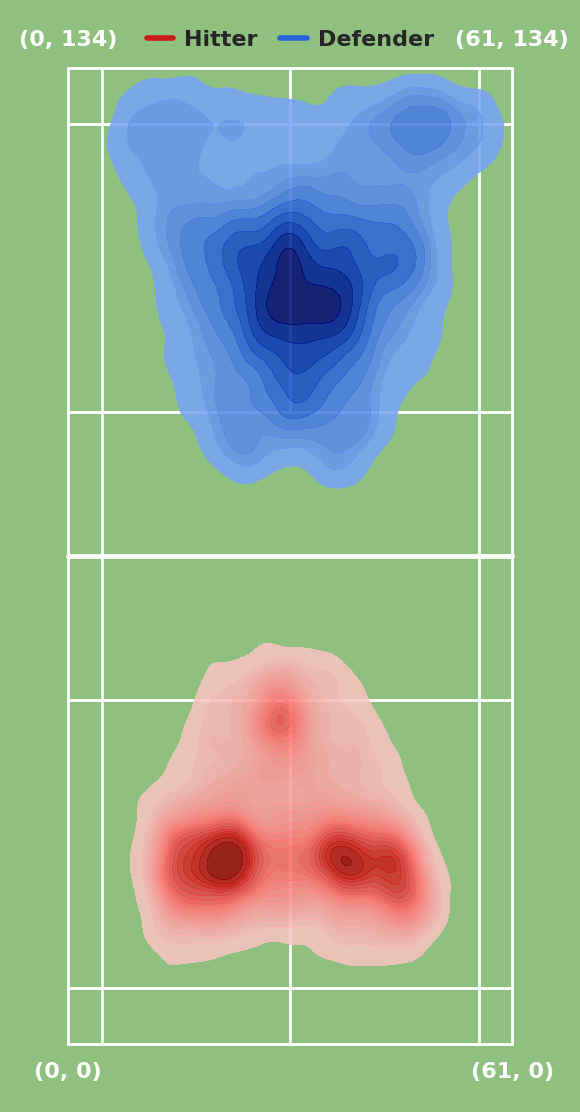

img/shottype_pos/drive.png (400 DPI) successfully saved!


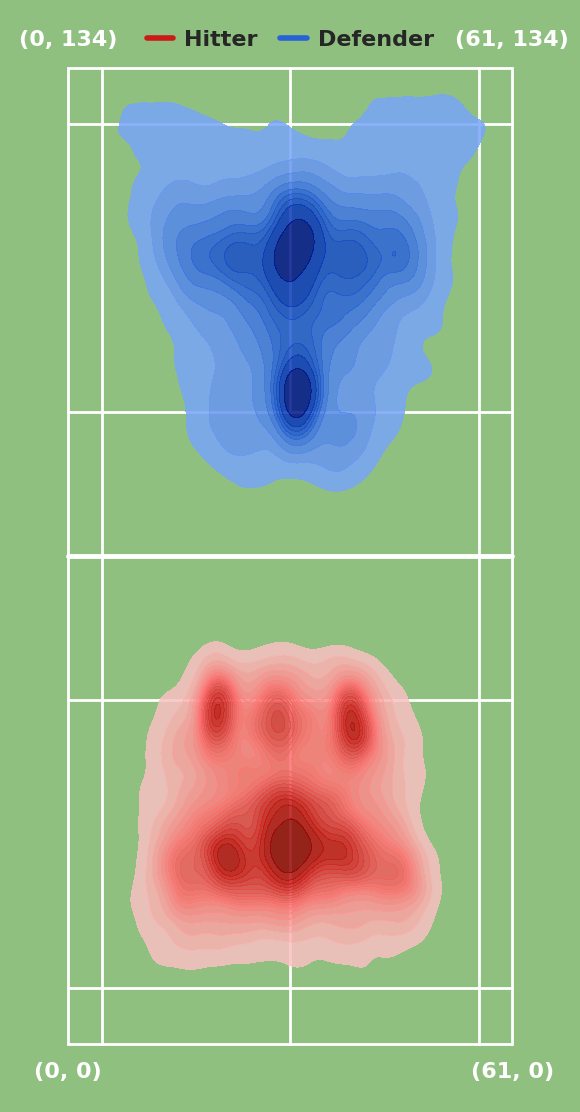

img/shottype_pos/net shot.png (400 DPI) successfully saved!


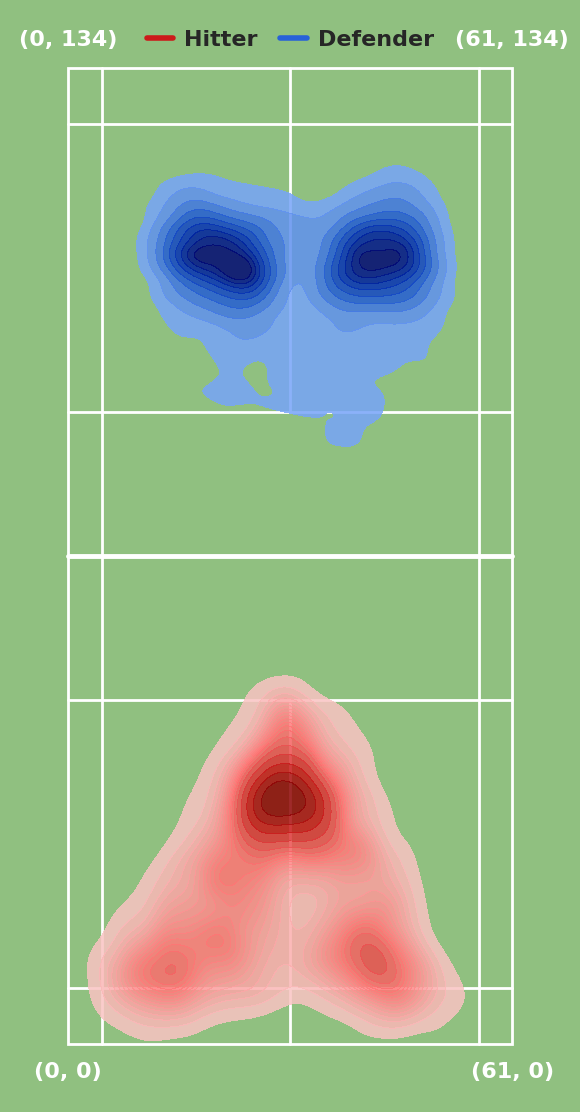

img/shottype_pos/clear.png (400 DPI) successfully saved!


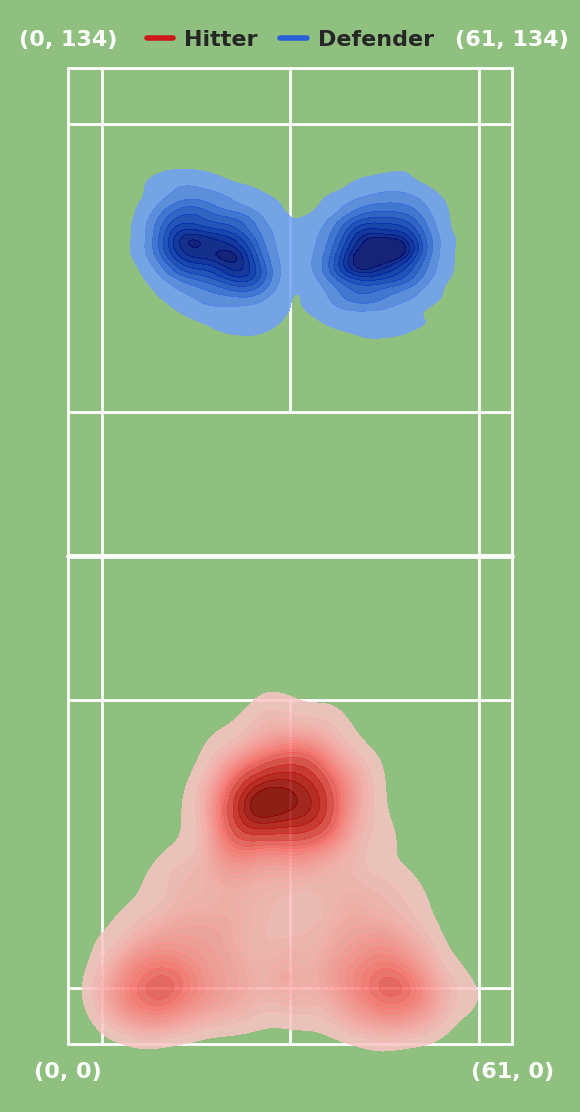

img/shottype_pos/drop.png (400 DPI) successfully saved!


In [10]:
from src.analysis.shottype_pos import prepare_occupancy_data, draw_attack_defense_map
balltype = ['smash','push','lift','drive','net shot','clear','drop']
no_serve_df = full_df[full_df['ball_type'] != 'short serve'].copy()
no_serve_df = no_serve_df[no_serve_df['ball_type'] != 'long serve'].copy()
for bt in balltype:
    df = no_serve_df[no_serve_df['ball_type'] == bt].copy()
    df = prepare_occupancy_data(df)
    draw_attack_defense_map(df,filename=f"img/shottype_pos/{bt}.png")

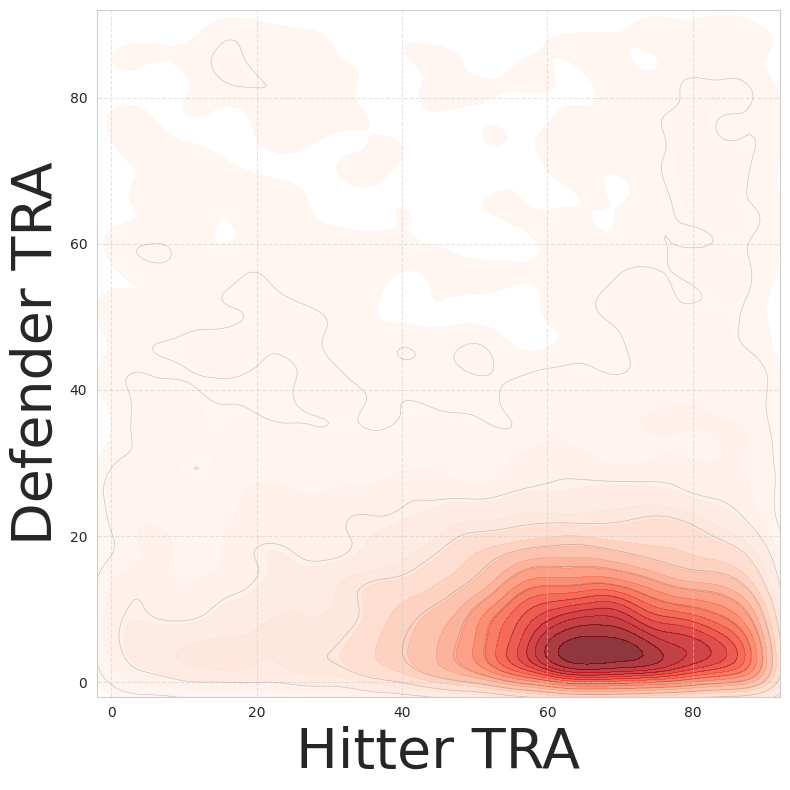

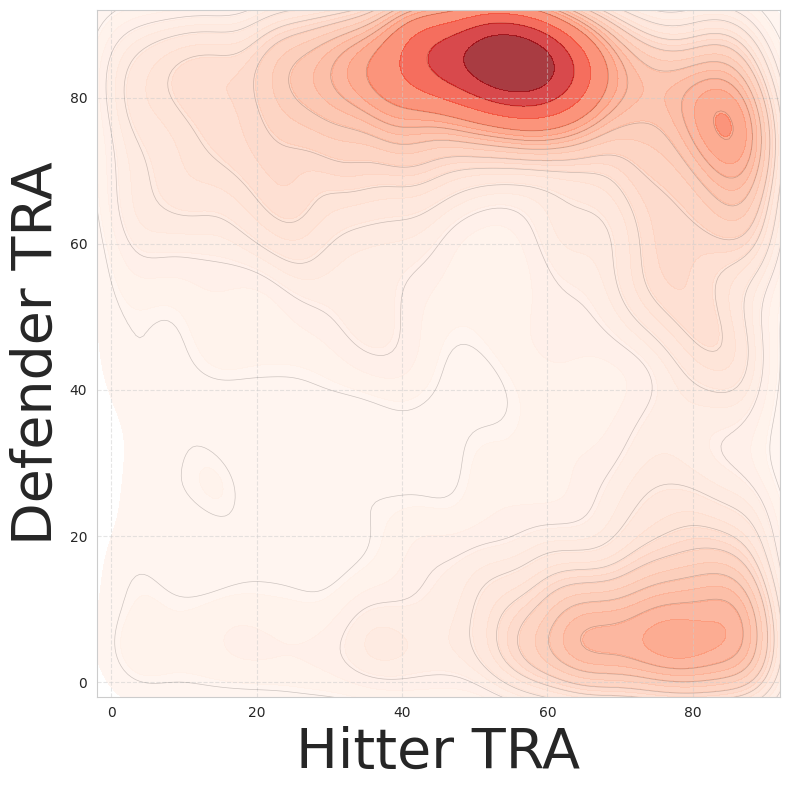

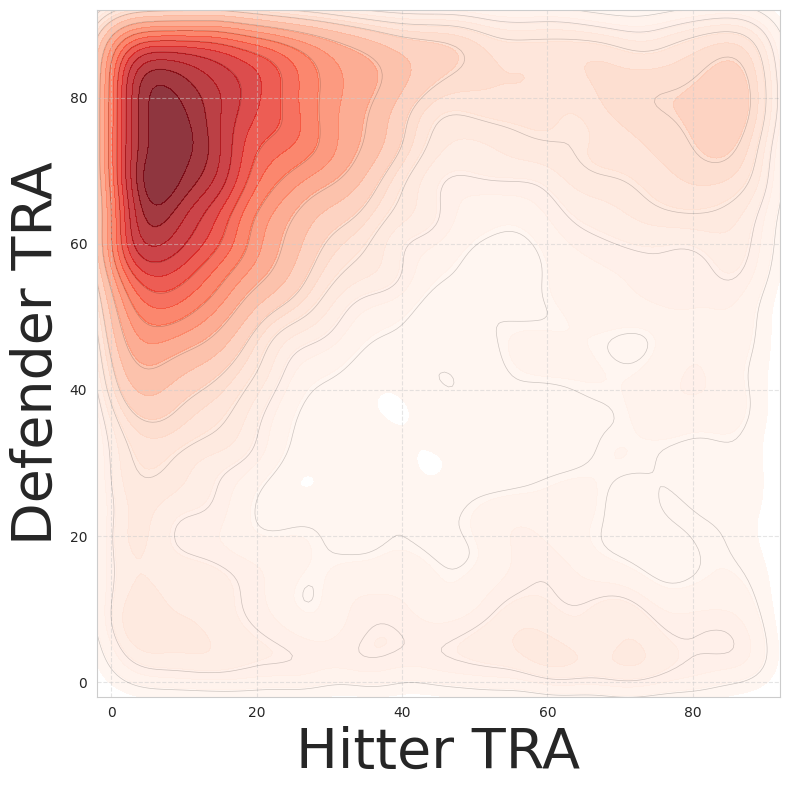

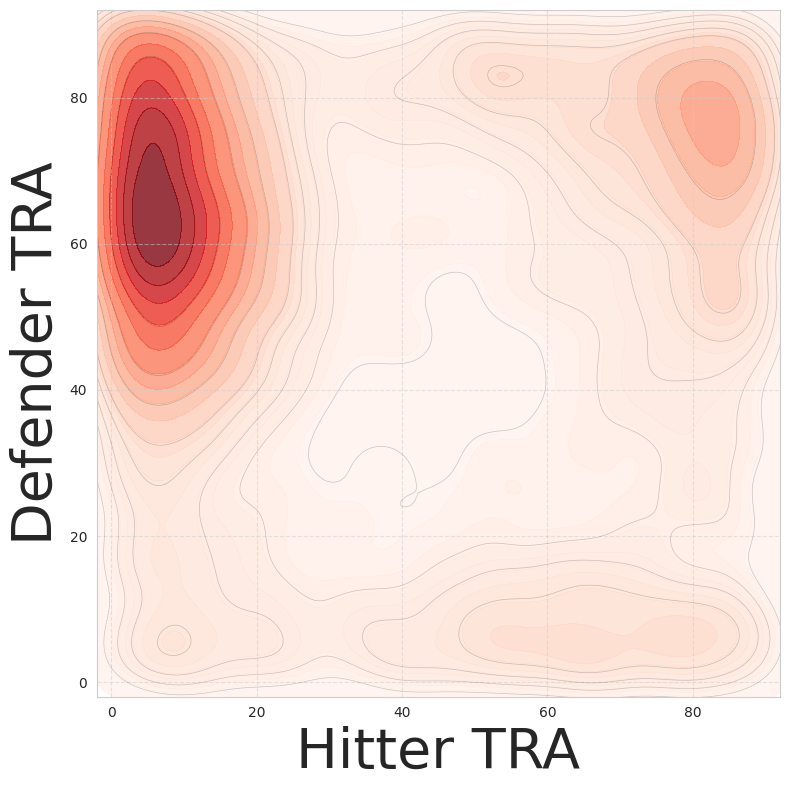

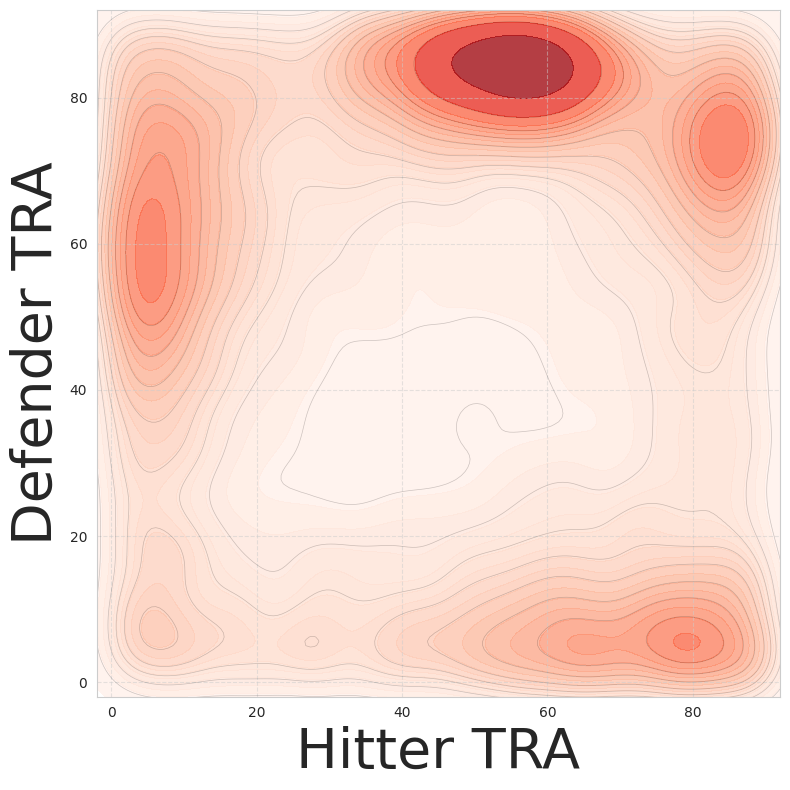

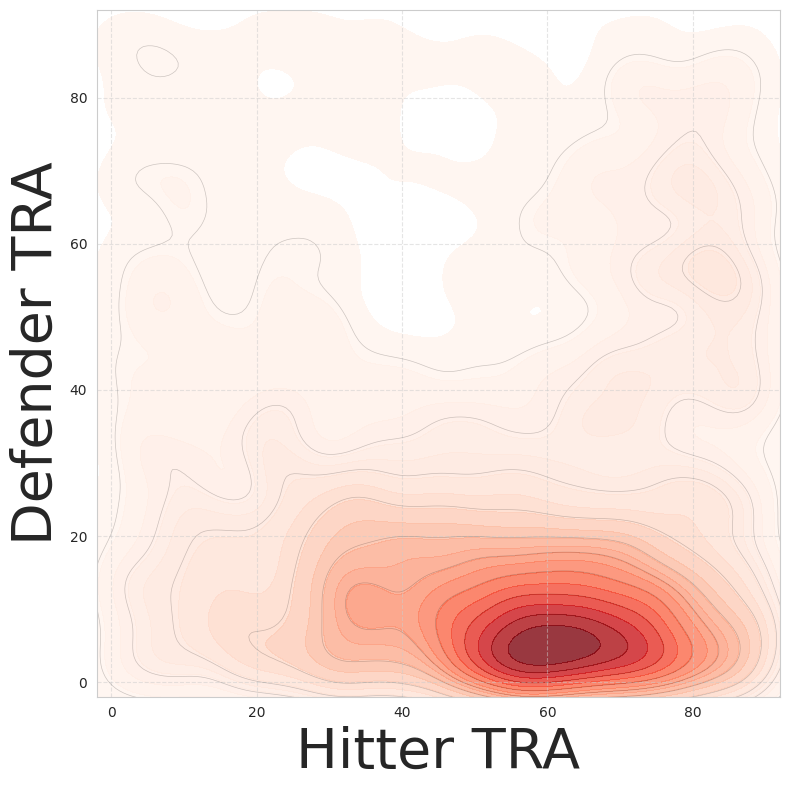

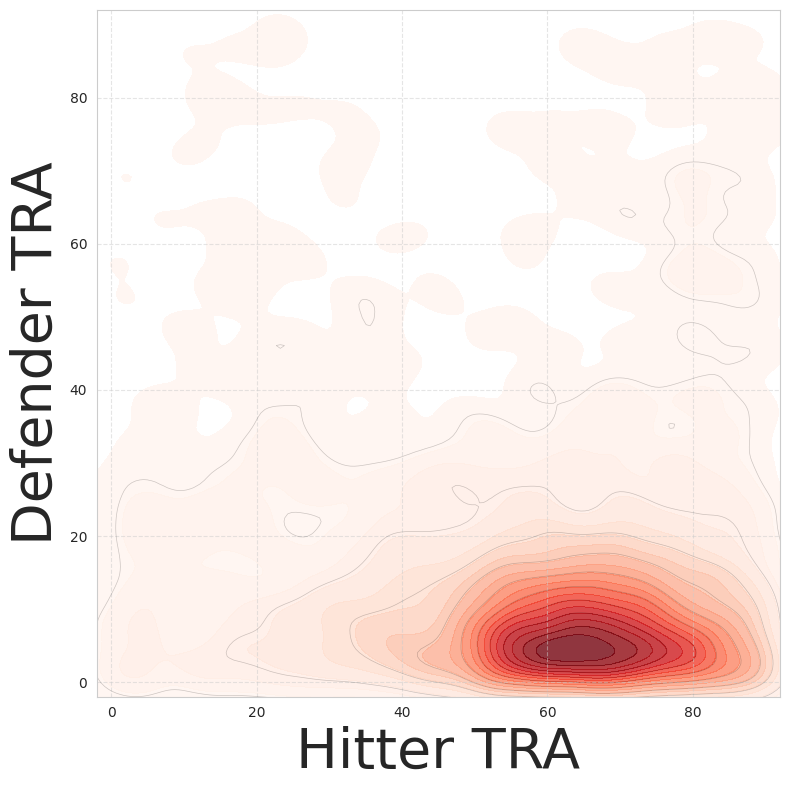

In [11]:
from src.analysis.shottype_heatmap import normalize_halfcourt, plot_angle_relation_scatter
from src.analysis.shottype_pos import prepare_occupancy_data
balltype = ['smash','push','lift','drive','net shot','clear','drop']

for bt in balltype:
    df = no_serve_df[no_serve_df['ball_type'] == bt].copy()
    df = normalize_halfcourt(df)
    df = prepare_occupancy_data(df)
    plot_angle_relation_scatter(df, title="Attack and Defend",filename=f"img/shottype_heatmap/{bt}.png")